Laboratorio de Regresión Polinomial

In [4]:

import numpy as np
import pandas as pd
from matplotlib import pyplot
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [5]:

print("="*50)
print("CARGANDO DATASET")
print("="*50)

ruta_dataset = '/content/drive/MyDrive/SIS420/datasets/YearPredictionMSD.csv'

import os
if not os.path.exists(ruta_dataset):
    print(f"ERROR: No se encontró el archivo en: {ruta_dataset}")
    print("Primero ejecuta el código para guardar el dataset en Drive.")
    print("O verifica que la ruta sea correcta.")
    raise FileNotFoundError(f"No se encontró el archivo: {ruta_dataset}")

df = pd.read_csv(ruta_dataset)

# Separar características y target
X = df.drop('Year', axis=1).values
y = df['Year'].values

m = y.shape[0]
n = X.shape[1]

print(f"Ejemplos (m): {m:,}")
print(f"Características (n): {n}")




CARGANDO DATASET
Ejemplos (m): 515,345
Características (n): 90


In [16]:
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

def computeCostMulti(X, y, theta):
    m = y.shape[0]
    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J

def gradientDescentMulti(X, y, theta, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []
    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))
    return theta, J_history

def normalEqn(X, y):
    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T, X)), X.T), y)
    return theta



MODELO 1: REGRESIÓN LINEAL MÚLTIPLE
Usando muestra de 10000 ejemplos para entrenamiento


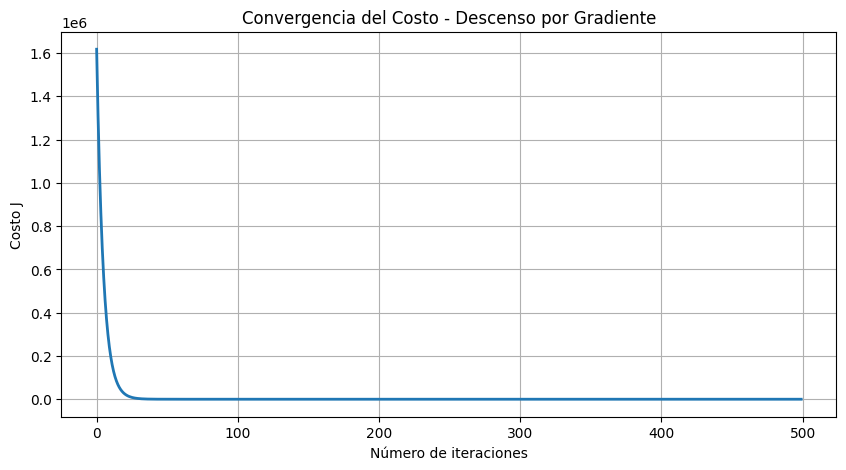

MSE: 85.8517
RMSE: 9.2656 años
R²: 0.2260


In [17]:
#MODELO 1: REGRESIÓN LINEAL MÚLTIPLE

print("\n" + "="*50)
print("MODELO 1: REGRESIÓN LINEAL MÚLTIPLE")
print("="*50)


sample_size = 10000  # 10,000 ejemplos para pruebas rápidas
np.random.seed(42)
indices = np.random.choice(m, sample_size, replace=False)
X_sample = X[indices]
y_sample = y[indices]

print(f"Usando muestra de {sample_size} ejemplos para entrenamiento")

# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(X_sample, y_sample, test_size=0.2, random_state=42)

# Normalizar
X_train_norm, mu, sigma = featureNormalize(X_train)

# Añadir columna de unos
X_train_with_bias = np.concatenate([np.ones((X_train_norm.shape[0], 1)), X_train_norm], axis=1)

# Entrenar
alpha = 0.1
num_iters = 500
theta_initial = np.zeros(X_train_with_bias.shape[1])
theta_gd, J_history_gd = gradientDescentMulti(X_train_with_bias, y_train, theta_initial, alpha, num_iters)

# Graficar costo
pyplot.figure(figsize=(10, 5))
pyplot.plot(np.arange(len(J_history_gd)), J_history_gd, lw=2)
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del Costo - Descenso por Gradiente')
pyplot.grid(True)
pyplot.show()

# Evaluar
X_test_norm = (X_test - mu) / sigma
X_test_with_bias = np.concatenate([np.ones((X_test_norm.shape[0], 1)), X_test_norm], axis=1)
y_pred_gd = np.dot(X_test_with_bias, theta_gd)

mse_gd = mean_squared_error(y_test, y_pred_gd)
r2_gd = r2_score(y_test, y_pred_gd)
rmse_gd = np.sqrt(mse_gd)

print(f"MSE: {mse_gd:.4f}")
print(f"RMSE: {rmse_gd:.4f} años")
print(f"R²: {r2_gd:.4f}")



MODELO 2: REGRESIÓN POLINÓMICA
Grado 2: MSE=103.4341, R²=0.0675
Grado 3: MSE=103.4033, R²=0.0678
Grado 4: MSE=103.2605, R²=0.0691

 Mejor grado: 4
MSE: 103.2605
RMSE: 10.1617 años
R²: 0.0691


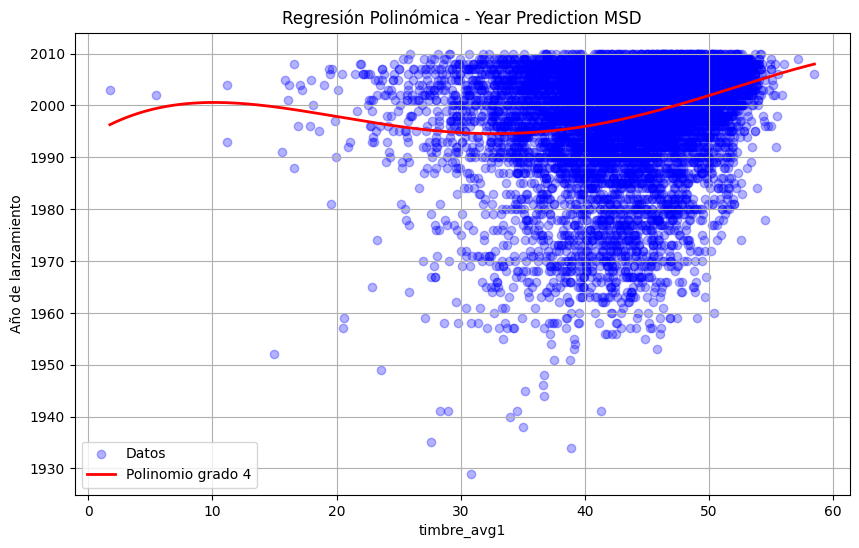

In [8]:
# MODELO 2:REGRESIÓN POLINÓMICA

print("\n" + "="*50)
print("MODELO 2: REGRESIÓN POLINÓMICA")
print("="*50)

# Usar una característica
X_poly = X_sample[:, 0].reshape(-1, 1)
y_poly = y_sample

# Dividir
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_poly, y_poly, test_size=0.2, random_state=42)

# Escalar
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_p)
X_test_scaled = scaler.transform(X_test_p)

# Probar grados
degrees = [2, 3, 4]
best_degree = 2
best_r2 = -np.inf
best_model = None
best_poly = None

for degree in degrees:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_scaled)
    X_test_poly = poly.transform(X_test_scaled)
    model = LinearRegression()
    model.fit(X_train_poly, y_train_p)
    y_pred = model.predict(X_test_poly)
    r2 = r2_score(y_test_p, y_pred)
    mse = mean_squared_error(y_test_p, y_pred)
    print(f"Grado {degree}: MSE={mse:.4f}, R²={r2:.4f}")
    if r2 > best_r2:
        best_r2 = r2
        best_degree = degree
        best_model = model
        best_poly = poly

# Evaluar mejor modelo
X_test_poly = best_poly.transform(X_test_scaled)
y_pred_poly = best_model.predict(X_test_poly)
mse_poly = mean_squared_error(y_test_p, y_pred_poly)
r2_poly = r2_score(y_test_p, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)

print(f"\n Mejor grado: {best_degree}")
print(f"MSE: {mse_poly:.4f}")
print(f"RMSE: {rmse_poly:.4f} años")
print(f"R²: {r2_poly:.4f}")

# Visualizar
X_vis = np.linspace(X_poly.min(), X_poly.max(), 200).reshape(-1, 1)
X_vis_scaled = scaler.transform(X_vis)
X_vis_poly = best_poly.transform(X_vis_scaled)
y_vis = best_model.predict(X_vis_poly)

pyplot.figure(figsize=(10, 6))
pyplot.scatter(X_poly, y_poly, c='blue', alpha=0.3, label='Datos')
pyplot.plot(X_vis, y_vis, 'r-', linewidth=2, label=f'Polinomio grado {best_degree}')
pyplot.xlabel('timbre_avg1')
pyplot.ylabel('Año de lanzamiento')
pyplot.title('Regresión Polinómica - Year Prediction MSD')
pyplot.legend()
pyplot.grid(True)
pyplot.show()



In [9]:

# MODELO 3: ECUACIÓN DE LA NORMAL
print("\n" + "="*50)
print("MODELO 3: ECUACIÓN DE LA NORMAL")
print("="*50)

# Preparar datos
X_eq = np.concatenate([np.ones((X_sample.shape[0], 1)), X_sample], axis=1)
X_train_eq, X_test_eq, y_train_eq, y_test_eq = train_test_split(X_eq, y_sample, test_size=0.2, random_state=42)

# Calcular theta
theta_eq = normalEqn(X_train_eq, y_train_eq)

# Evaluar
y_pred_eq = np.dot(X_test_eq, theta_eq)
mse_eq = mean_squared_error(y_test_eq, y_pred_eq)
r2_eq = r2_score(y_test_eq, y_pred_eq)
rmse_eq = np.sqrt(mse_eq)

print(f"MSE: {mse_eq:.4f}")
print(f"RMSE: {rmse_eq:.4f} años")
print(f"R²: {r2_eq:.4f}")




MODELO 3: ECUACIÓN DE LA NORMAL
MSE: 85.8538
RMSE: 9.2657 años
R²: 0.2260


In [11]:
#COMPARACIÓN Y 100 PREDICCIONES

print("\n" + "="*50)
print("COMPARACIÓN DE MODELOS")
print("="*50)

print(f"{'Modelo':<30} {'MSE':<15} {'RMSE':<12} {'R²':<10}")
print("-"*70)
print(f"{'Descenso por Gradiente':<30} {mse_gd:.4f}       {rmse_gd:.4f}     {r2_gd:.4f}")
print(f"{'Polinómico (grado '+str(best_degree)+')':<30} {mse_poly:.4f}       {rmse_poly:.4f}     {r2_poly:.4f}")
print(f"{'Ecuación de la Normal':<30} {mse_eq:.4f}       {rmse_eq:.4f}     {r2_eq:.4f}")

print("\n" + "="*50)
print("REALIZANDO 100 PREDICCIONES")
print("="*50)

# Generar 100 predicciones
np.random.seed(42)
X_pred = np.random.uniform(X_sample.min(axis=0), X_sample.max(axis=0), size=(100, X_sample.shape[1]))

pred_gd = []
pred_poly = []
pred_eq = []

for i in range(100):
    # Gradiente
    X_pred_norm = (X_pred[i:i+1] - mu) / sigma
    X_pred_bias = np.concatenate([[1], X_pred_norm.flatten()])
    pred_gd.append(np.dot(X_pred_bias, theta_gd))

    # Polinómico
    pred_scaled = scaler.transform([[X_pred[i, 0]]])
    pred_feat = best_poly.transform(pred_scaled)
    pred_poly.append(best_model.predict(pred_feat)[0])

    # Normal
    X_pred_eq = np.concatenate([[1], X_pred[i:i+1].flatten()])
    pred_eq.append(np.dot(X_pred_eq, theta_eq))

print(f"Estadísticas de las 100 predicciones:")
print("-"*50)
print(f"Gradiente  - Media: {np.mean(pred_gd):.1f} años, Std: {np.std(pred_gd):.1f}")
print(f"Polinómico - Media: {np.mean(pred_poly):.1f} años, Std: {np.std(pred_poly):.1f}")
print(f"Normal     - Media: {np.mean(pred_eq):.1f} años, Std: {np.std(pred_eq):.1f}")




COMPARACIÓN DE MODELOS
Modelo                         MSE             RMSE         R²        
----------------------------------------------------------------------
Descenso por Gradiente         85.8517       9.2656     0.2260
Polinómico (grado 4)           103.2605       10.1617     0.0691
Ecuación de la Normal          85.8538       9.2657     0.2260

REALIZANDO 100 PREDICCIONES
Estadísticas de las 100 predicciones:
--------------------------------------------------
Gradiente  - Media: 2012.3 años, Std: 28.7
Polinómico - Media: 1998.6 años, Std: 3.2
Normal     - Media: 2011.9 años, Std: 28.8
